In [400]:
import numpy as np
from numpy.fft import fft2, ifft2, fftshift, ifftshift, fftfreq
import matplotlib.pyplot as plt

from skimage.data import cells3d
from skimage.filters import gaussian

In [401]:
def pwr(x: np.ndarray) -> np.ndarray:
    """Compute the power spectrum of an image."""
    ft = fft2(x)
    # ft = np.log10(np.abs(ft) + 1e-10)  # Add a small constant to avoid log(0)
    ft = np.abs(ft)**0.2

    return fftshift(ft)

In [417]:
img = cells3d()[36:42, 0, :, :].max(0).astype(np.float32)
img -= img.min()

# filter
img = gaussian(img, sigma=(4.0, 2.0), channel_axis=-1, mode='wrap')

# normalize
img /= img.sum()

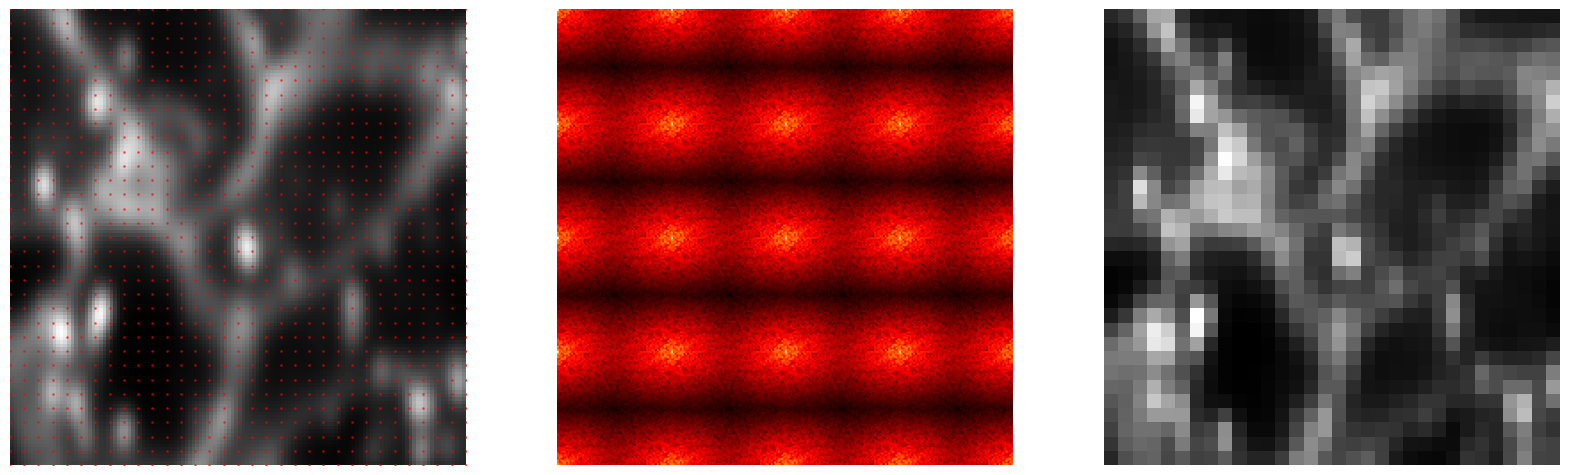

In [431]:
ds = 4

h_c = 64

ny, nx = img.shape
ext = [-nx//2, nx//2, -ny//2, ny//2]
ext = [-h_c, h_c, -h_c, h_c]

fig, ax = plt.subplots(1, 3, figsize=(20, 50))
ax[0].imshow(img[128-h_c:128+h_c, 128-h_c:128+h_c], cmap='gray', extent=ext)

if ds > 1:
    cx, cy = np.meshgrid(list(range(-h_c, 1+h_c, ds)), list(range(-h_c, 1+h_c, ds)))
    coords = np.stack([cx.flatten(), cy.flatten()], axis=1)
    ax[0].scatter(coords[:,0], coords[:,1], color='red', s=1, alpha=0.5)

ax[0].set_axis_off()

ax[2].imshow(img[128-h_c:128+h_c, 128-h_c:128+h_c][::ds, ::ds], cmap='gray', extent=ext)
ax[2].set_axis_off()

comb = np.zeros_like(img)
comb[::ds, ::ds] = 1
ax[1].imshow(pwr(img * comb), cmap='hot')
ax[1].set_axis_off()